In [4]:
import numpy as np
import joblib
import os
import warnings
from sklearn.exceptions import ConvergenceWarning
import time

# 1. Scikit-Learn 평가 도구 임포트
from scipy.ndimage import rotate, shift, zoom
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin, clone

# 불필요한 경고 메시지 숨기기
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning, module='sklearn')

print("--- 1. 평가에 필요한 모듈 로드 완료 ---")

--- 1. 평가에 필요한 모듈 로드 완료 ---


In [16]:
import glob
import os

# --- 2. 파일 목록 정의 (자동 로드) ---
# 'train code' 폴더 내의 패턴에 맞는 모든 .joblib 파일을 찾습니다.
# 예: train code 폴더 안의 "..._best_0-1.joblib"로 끝나는 모든 파일
model_search_pattern = 'train code/pipeline/com/stacking_mlp+rf+knn_KNN.joblib'
model_files = sorted(glob.glob(model_search_pattern))

# 파일이 제대로 찾아졌는지 확인
print(f"--- 총 {len(model_files)}개의 모델 파일을 찾았습니다 ---")
for f in model_files:
    print(f" -> {f}")

# (수정 완료된) Hand-made 테스트 데이터
# handmade_data_file = 'mnist_sklearn_all_70000.npz'
handmade_data_file = 'train code/SMNIST_test_25.npz'

--- 총 1개의 모델 파일을 찾았습니다 ---
 -> train code/pipeline/com/stacking_mlp+rf+knn_KNN.joblib


In [17]:
# --- 3. Hand-made 테스트 데이터 로드 ---
print(f"\n--- 2. Hand-made 테스트 데이터 '{handmade_data_file}' 로드 ---")

if not os.path.exists(handmade_data_file):
    print(f"[오류] 테스트 데이터 '{handmade_data_file}'을 찾을 수 없습니다!")
    print("-> 이전 단계에서 데이터 병합 및 저장을 먼저 실행하세요.")
else:
    with np.load(handmade_data_file, allow_pickle=True) as data:
        print(data)
        if 'img' in data and 'label' in data:
            X_test = data['img']
            y_test = data['label']
        elif 'x_train' in data and 'y_train' in data:
            X_test = data['x_train']
            y_test = data['y_train']
        elif 'images' in data and 'labels' in data:
            X_test = data['images']
            y_test = data['labels']
        else:
            X_test = data['X']
            y_test = data['y'] # 이 y_test가 "실제 정답"
            
X_test = X_test.reshape(-1, 784)

if keras:
    X_test = x_train_keras
    y_test = y_train_keras

print(f"  > 테스트 데이터 로드 성공. X_test: {X_test.shape}, y_test: {y_test.shape}")


--- 2. Hand-made 테스트 데이터 'train code/SMNIST_test_25.npz' 로드 ---
NpzFile 'train code/SMNIST_test_25.npz' with keys: img, label
  > 테스트 데이터 로드 성공. X_test: (2500, 784), y_test: (2500,)


In [19]:
# ==========================================
# 1. 사용자 정의 전처리 클래스
# ==========================================
class CustomImagePreprocess(BaseEstimator, TransformerMixin):
    def __init__(self, stroke_target=0.4, target_size=20, final_size=28, noise_threshold=0.02):
        self.stroke_target = stroke_target       
        self.target_size = target_size           
        self.final_size = final_size             
        self.noise_threshold = noise_threshold   
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X, y=None):
        X = np.array(X)
        if X.ndim == 2:
            side = int(np.sqrt(X.shape[1]))
            X = X.reshape(-1, side, side)
        
        processed = []
        for img in X:
            img = self.normalize_scale(img)   
            img = self.remove_noise(img)      
            img = self.normalize_stroke(img)  
            img = self.normalize_size(img)    
            img = self.center_align(img)
            processed.append(img)
        
        processed = np.array(processed)
        return processed.reshape(len(processed), -1)
    
    # --- 내부 메서드 ---
    def normalize_scale(self, img):
        img = img.astype(np.float32)
        if img.max() > 1: img = img / 255.0
        return img
    
    def remove_noise(self, img):
        img = img.copy()
        img[img < self.noise_threshold] = 0.0
        return img
    
    def normalize_stroke(self, img):
        mask = img > 0.05
        if mask.sum() == 0: return img
        mean_val = img[mask].mean()
        if mean_val == 0: return img
        scale_factor = self.stroke_target / mean_val
        img = img * scale_factor
        img = np.clip(img, 0, 1)
        return img
    
    def normalize_size(self, img):
        coords = np.where(img > 0.05)
        if coords[0].size == 0: return np.zeros((self.final_size, self.final_size))
        r1, r2 = coords[0].min(), coords[0].max()
        c1, c2 = coords[1].min(), coords[1].max()
        digit = img[r1:r2+1, c1:c2+1]
        h, w = digit.shape
        if h == 0 or w == 0: return np.zeros((self.final_size, self.final_size))
        zoom_h = self.target_size / h
        zoom_w = self.target_size / w
        digit_resized = zoom(digit, (zoom_h, zoom_w))
        return digit_resized
    
    def center_align(self, img):
        canvas = np.zeros((self.final_size, self.final_size))
        h, w = img.shape
        if h > self.final_size or w > self.final_size:
            h_start = (h - self.final_size) // 2
            w_start = (w - self.final_size) // 2
            img = img[h_start:h_start+self.final_size, w_start:w_start+self.final_size]
            h, w = img.shape
        y0 = (self.final_size - h) // 2
        x0 = (self.final_size - w) // 2
        canvas[y0:y0+h, x0:x0+w] = img
        return canvas

class ForceFittedClassifier(BaseEstimator, ClassifierMixin):
    # "학습됨" 상태를 강제로 인식시키는 래퍼 (NotFittedError 방지용)
    def __init__(self, estimator):
        self.estimator = estimator
    def fit(self, X, y=None): return self
    def predict(self, X): return self.estimator.predict(X)
    def predict_proba(self, X): return self.estimator.predict_proba(X)
    def __sklearn_is_fitted__(self): return True

class PreFittedVotingClassifier(BaseEstimator, ClassifierMixin):
    # 재학습 없는 Voting 클래스
    def __init__(self, estimators):
        self.estimators = estimators
    def fit(self, X, y): return self
    def predict(self, X):
        probas = self.predict_proba(X)
        return np.argmax(probas, axis=1)
    def predict_proba(self, X):
        avg_proba = None
        for _, model in self.estimators:
            proba = model.predict_proba(X)
            if avg_proba is None: avg_proba = proba
            else: avg_proba += proba
        return avg_proba / len(self.estimators)

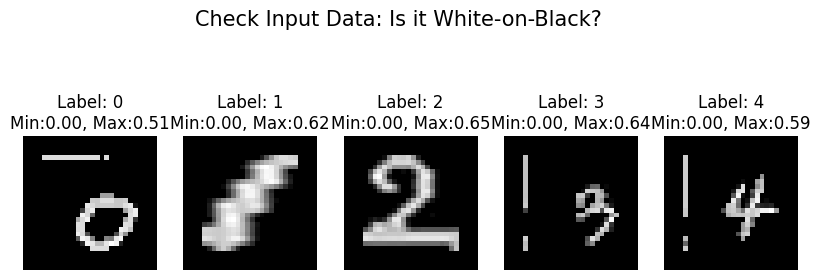


--- 3. 8개 모델 성능 평가 시작 ---

 [1/1] 평가 중: train code/pipeline/com/stacking_mlp+rf+knn_KNN.joblib
  > 예측 완료 (소요 시간: 2.2808초)
  > **Accuracy (정확도): 77.60%**

  --- Classification Report (정밀도/재현율/F1) ---
              precision    recall  f1-score   support

           0     0.6160    0.5840    0.5996       250
           1     0.7908    0.6200    0.6951       250
           2     0.7637    0.7240    0.7433       250
           3     0.8619    0.7240    0.7870       250
           4     0.8780    0.8640    0.8710       250
           5     0.6463    0.8480    0.7336       250
           6     0.8529    0.9280    0.8889       250
           7     0.7044    0.8960    0.7887       250
           8     0.8640    0.7880    0.8243       250
           9     0.8596    0.7840    0.8201       250

    accuracy                         0.7760      2500
   macro avg     0.7838    0.7760    0.7751      2500
weighted avg     0.7838    0.7760    0.7751      2500



In [23]:
# ==========================================
# [수정 제안] 전처리 적용 후 평가하기
# ==========================================
#### --- 4. 8개 모델 순차 평가 ---

preprocessor = CustomImagePreprocess()

X_test = preprocessor.transform(X_test)

import matplotlib.pyplot as plt

# 1. 데이터 샘플 시각화 (모델에 들어가기 직전 상태 확인)
plt.figure(figsize=(10, 4))
for i in range(5):
    ax = plt.subplot(1, 5, i + 1)
    # reshape해서 이미지로 복원
    img = X_test[i].reshape(28, 28)
    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {y_test[i]}\nMin:{img.min():.2f}, Max:{img.max():.2f}")
    plt.axis('off')
plt.suptitle("Check Input Data: Is it White-on-Black?", fontsize=15)
plt.show()

print("\n--- 3. 8개 모델 성능 평가 시작 ---")

results = []

for i, model_name in enumerate(model_files):
    print(f"\n=============================================")
    print(f" [{i+1}/{len(model_files)}] 평가 중: {model_name.replace('train code/pipeline/base/', '')}")
    print(f"=============================================")
    
    if not os.path.exists(model_name):
        print(f"  [오류] 모델 파일 '{model_name}'을 찾을 수 없습니다! 'run_all.sh'를 먼저 실행하세요.")
        continue
        
    # 모델 로드
    model = joblib.load(model_name)
    # if 'final_decisiontree_v1' in model_name:
    #     X_test = X_test/255
    
    # 예측 수행
    start_time = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start_time
    
    # 평가
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, digits=4, zero_division=0)
    cm = confusion_matrix(y_test, y_pred, labels=np.arange(10))
    
    print(f"  > 예측 완료 (소요 시간: {pred_time:.4f}초)")
    print(f"  > **Accuracy (정확도): {accuracy * 100:.2f}%**")
    
    print("\n  --- Classification Report (정밀도/재현율/F1) ---")
    print(report)
    
    # (수정) 예측 결과(y_pred)도 함께 저장
    results.append({
        'name': model_name.replace('train code/pipeline/com/', ''),
        'accuracy': accuracy,
        'cm': cm,
        'y_pred': y_pred  # 오류 분석을 위해 예측값 저장
    })

In [24]:
# --- 5. 최종 요약 및 Confusion Matrix 시각화 ---
print("\n--- 4. 최종 성능 요약 (Accuracy 기준 내림차순) ---")

# 정확도 기준으로 결과 정렬
results_sorted = sorted(results, key=lambda x: x['accuracy'], reverse=True)

for res in results_sorted:
    print(f"  - {res['name']:<25} | Accuracy: {res['accuracy'] * 100:.2f}%")

print("\n--- 5. 8개 모델 Confusion Matrix 시각화 ---")

# 2x4 격자로 8개 Confusion Matrix 그리기
fig_cm, axes_cm = plt.subplots(2, 4, figsize=(22, 10))
fig_cm.suptitle("Confusion Matrices: Original Models vs. Hand-made Data", fontsize=20)

for i, res in enumerate(results):
    ax = axes_cm.flat[i]
    disp = ConfusionMatrixDisplay(confusion_matrix=res['cm'], display_labels=np.arange(10))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"{res['name']}\nAccuracy: {res['accuracy']:.3f}")
    
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

output_image_file = 'all_confusion_matrices.png'
plt.savefig(output_image_file)
print(f"\n[성공] 8개 모델의 혼동 행렬을 '{output_image_file}'로 저장했습니다.")
plt.close(fig_cm) # 메모리 해제


--- 4. 최종 성능 요약 (Accuracy 기준 내림차순) ---
  - stacking_mlp+rf+knn_KNN.joblib | Accuracy: 77.60%

--- 5. 8개 모델 Confusion Matrix 시각화 ---

[성공] 8개 모델의 혼동 행렬을 'all_confusion_matrices.png'로 저장했습니다.
